In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 



In [2]:
from snudd import config


In [4]:
from snudd.efficiencies import efficiency_lz_b8 # efficiency 

In [5]:
efficiency_lz_b8(2.0*1e-6)

array(0.07992865)

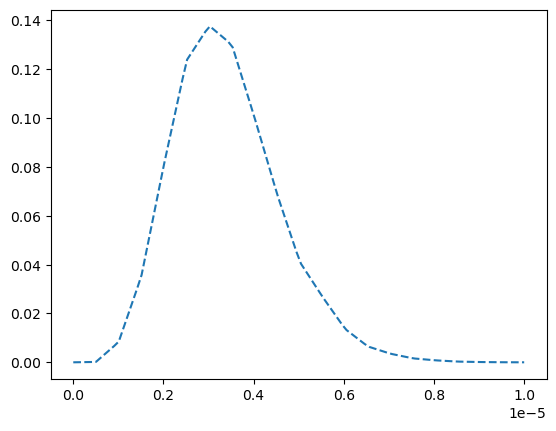

In [6]:
xspace = np.linspace(0.0 , 10*1e-6, 100)


plt.plot(xspace, efficiency_lz_b8(xspace), label="LZ B8 efficiency", ls='--')


In [7]:
from snudd.resolution import Resolution, Convolver # deals with the resolution effects on the rate

from snudd.resolution   import res_lz_nr


In [8]:
def counts_LZB8_NR(signal, E_Rs):
    #### from https://arxiv.org/pdf/2512.08065 
    exposure =  5.7 # in tn yr-1
    convolution_lz_sig = Convolver(E_Rs, signal , efficiency_lz_b8, res_lz_nr)
    return convolution_lz_sig.convolved_binned_rate(1.0e-7, 1.5e-5)*exposure 

In [9]:
E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered

In [10]:
from snudd.models  import GeneralNSI
from snudd.targets import Nucleus


In [11]:
SM_matrix = np.array([[0, 0, 0],
                       [0, 0.0, 0],
                       [0, 0, 0.0]])

eta = 0
phi = 0

sm_model = GeneralNSI(SM_matrix, eta, phi)

In [12]:
Z_xe = 54

# Isotopic weight with relative abundance
xe_iso_data = np.array([[124, 123.905893 * config.u, 0.00095],
                        [126, 125.904274 * config.u, 0.00089],
                        [128, 127.9035313 * config.u, 0.01910],
                        [129, 128.9047794 * config.u, 0.26401],
                        [130, 129.9035080 * config.u, 0.04071],
                        [131, 130.9050824 * config.u, 0.21232],
                        [132, 131.9041535 * config.u, 0.26909],
                        [134, 133.9053945 * config.u, 0.10436],
                        [136, 135.907219 * config.u, 0.08857]]) 

In [13]:

def unpack_isotope_data(isotope_data, Z):
    """Return array of nuclei for each isotope and array of isotopic factions given isotope data
    and the common atomic number.
    """
    
    nuclei = []
    iso_fractions = []

    for (A_iso, mass_iso, iso_fraction) in isotope_data:
        nuclei.append(Nucleus(Z, A_iso, mass=mass_iso))
        iso_fractions.append(iso_fraction)
    
    return np.array(nuclei), np.array(iso_fractions)

In [14]:
def average_isotope_spectra(nuclei, isotopic_fractions, E_Rs, model):
    """Return weighted mean of energy spectra given nuclei and isotopic fractions."""
    
    spectra_iso = np.zeros((len(nuclei), len(E_Rs)))
    
    for inucleus, nucleus in enumerate(nuclei):
        nucleus.update_model(model)
        if inucleus == 0:  # Only need to prepare density matrix for one isotope (same for all isotopes)
            #print('Preparing density matrix...')
            nucleus.prepare_density()
            #print('Done')
            prepared_density = nucleus._spec.nu_density_elements
        nucleus._spec.nu_density_elements = prepared_density
        spectrum_iso = nucleus.spectrum(E_Rs)
        spectra_iso[inucleus] = spectrum_iso
        
    return np.dot(isotopic_fractions, spectra_iso)  # Dot calculates weighted sum  

In [15]:
nuclei, iso_fractions = unpack_isotope_data(xe_iso_data, Z_xe)

In [16]:
sm_spec = average_isotope_spectra(nuclei, iso_fractions, E_Rs, sm_model) # Calculates the spectrum for the SM model 

/tmp/ipykernel_169886/855247466.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  spectra_iso[inucleus] = spectrum_iso


In [17]:
LZB8_counts = counts_LZB8_NR(sm_spec, E_Rs)

In [19]:
LZB8_counts  

20.178528292591988